# Farmer Price vs Retail Price — Vegetable Time Series
**Dataset:** `Final_Combined_data.csv`  
**Period:** 2013 – 2019 | **Vegetables:** 12

Loaded 61,152 rows | 12 vegetables | 2013–2019


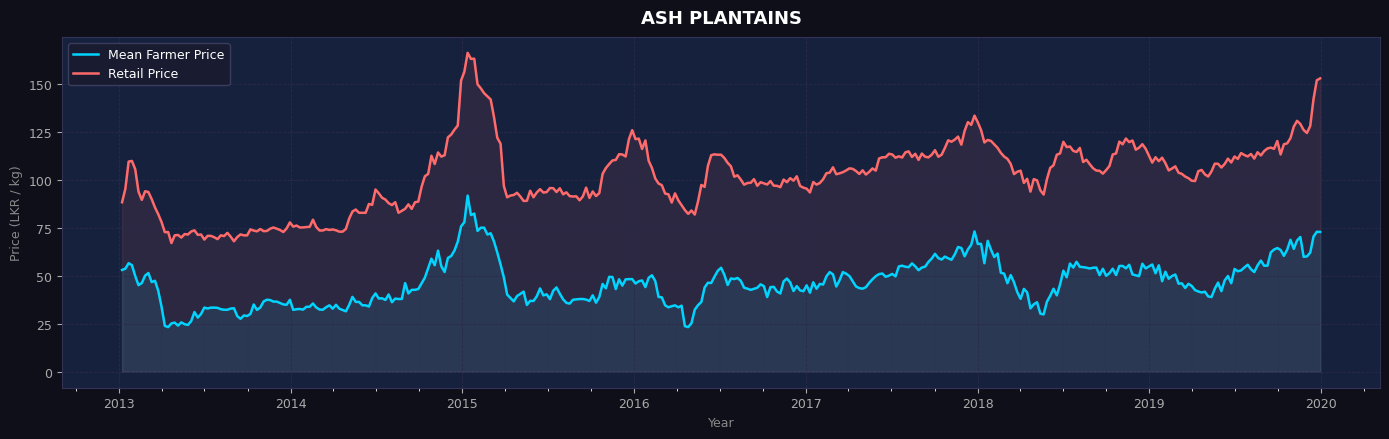

  ✔ ASH PLANTAINS saved → C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing\ASH_PLANTAINS_price_trend.png
    Farmer NaN: 0 | Retail NaN: 0


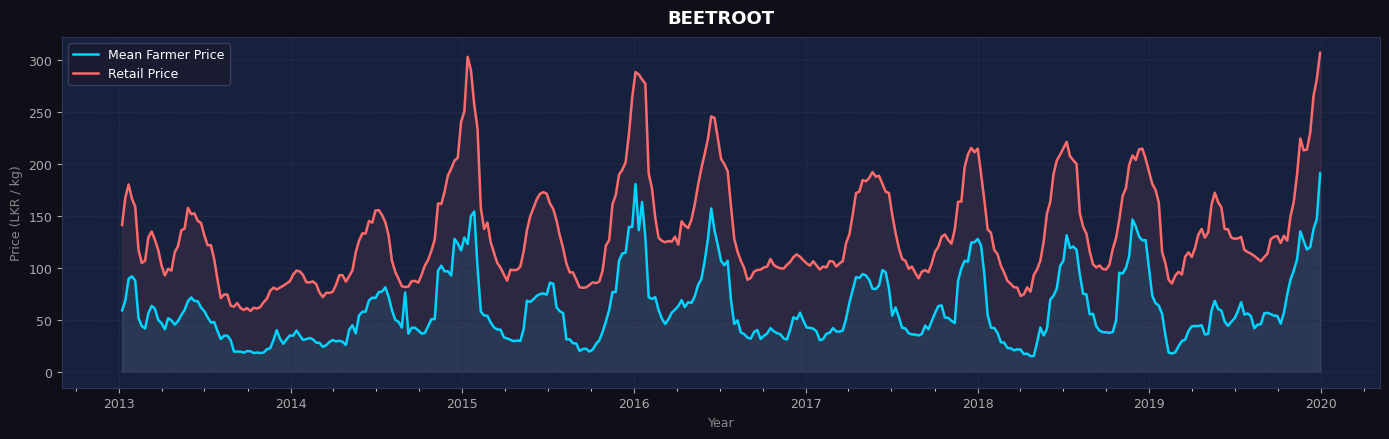

  ✔ BEETROOT saved → C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing\BEETROOT_price_trend.png
    Farmer NaN: 0 | Retail NaN: 0


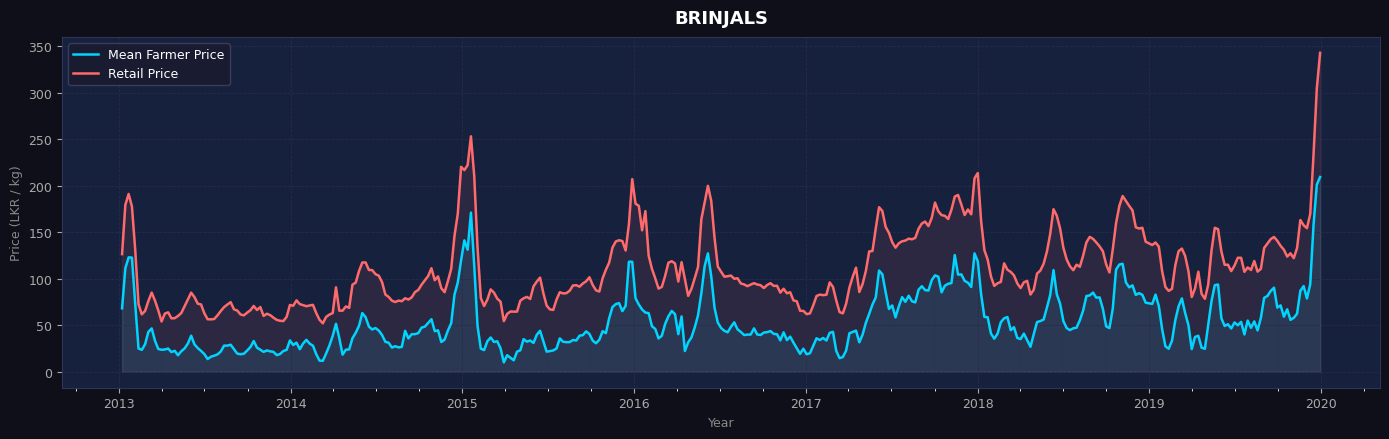

  ✔ BRINJALS saved → C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing\BRINJALS_price_trend.png
    Farmer NaN: 0 | Retail NaN: 0


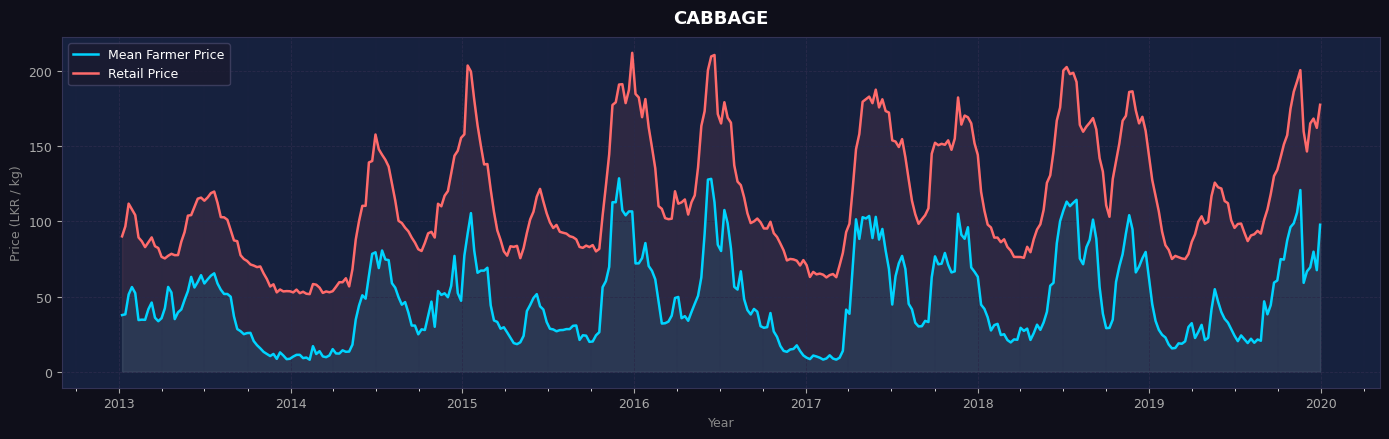

  ✔ CABBAGE saved → C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing\CABBAGE_price_trend.png
    Farmer NaN: 0 | Retail NaN: 0


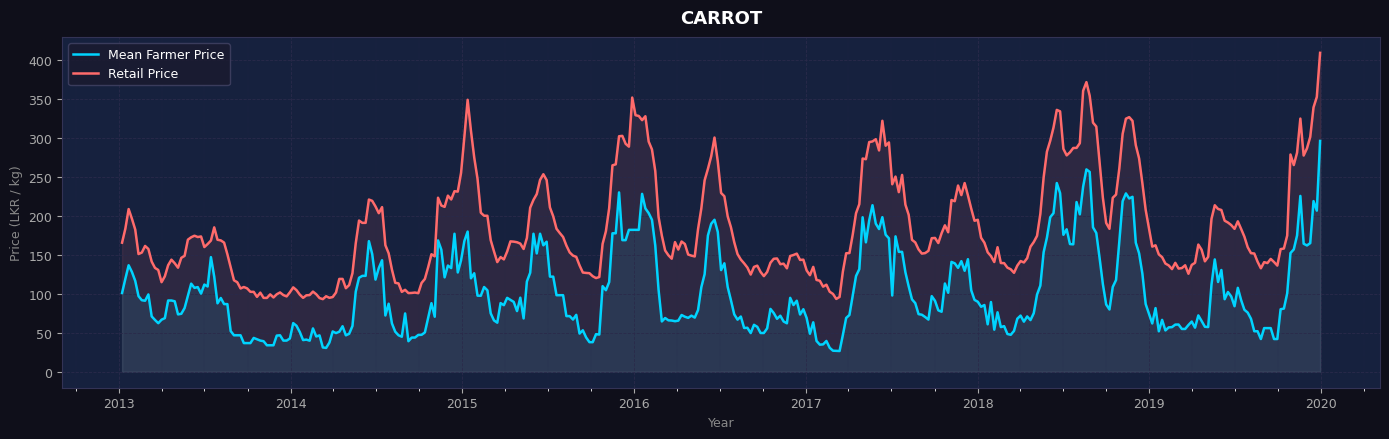

  ✔ CARROT saved → C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing\CARROT_price_trend.png
    Farmer NaN: 0 | Retail NaN: 0


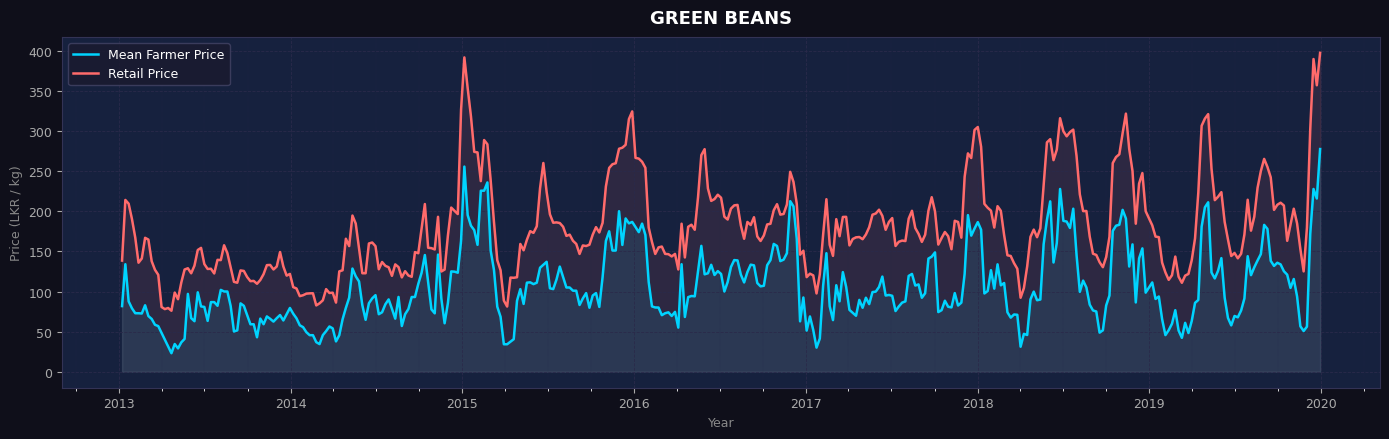

  ✔ GREEN BEANS saved → C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing\GREEN_BEANS_price_trend.png
    Farmer NaN: 0 | Retail NaN: 0


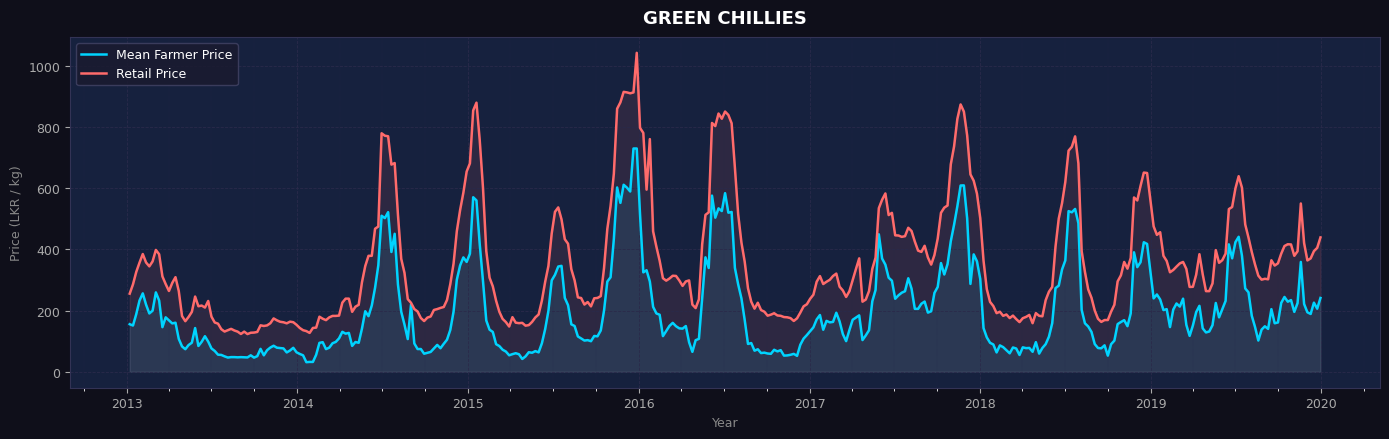

  ✔ GREEN CHILLIES saved → C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing\GREEN_CHILLIES_price_trend.png
    Farmer NaN: 0 | Retail NaN: 0


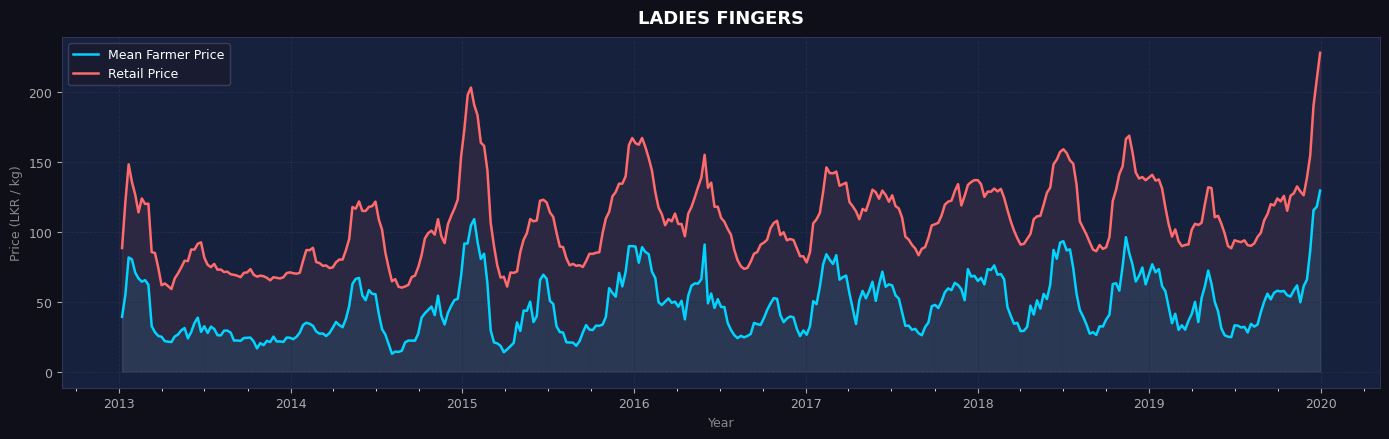

  ✔ LADIES FINGERS saved → C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing\LADIES_FINGERS_price_trend.png
    Farmer NaN: 0 | Retail NaN: 0


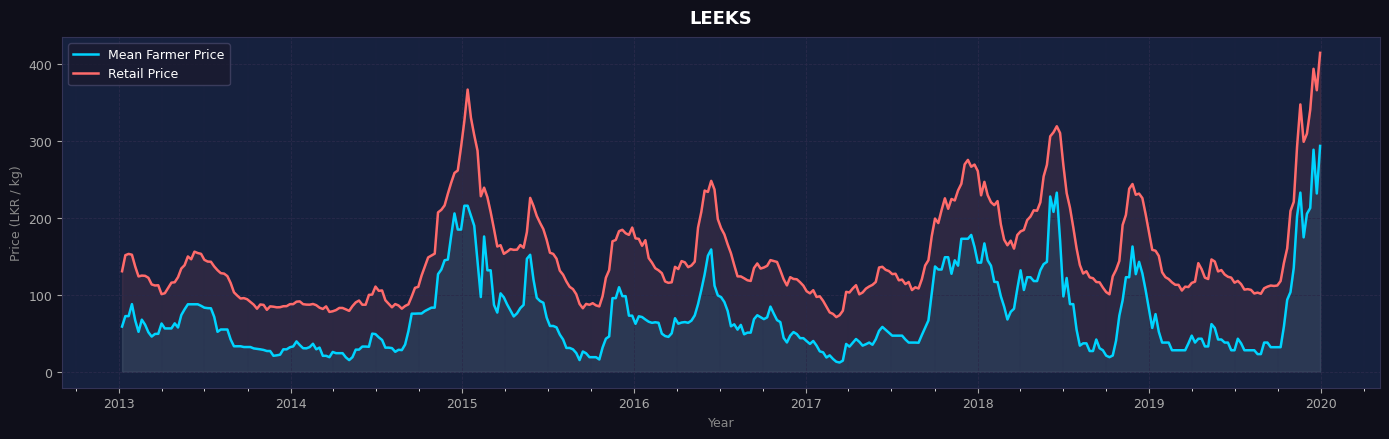

  ✔ LEEKS saved → C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing\LEEKS_price_trend.png
    Farmer NaN: 0 | Retail NaN: 0


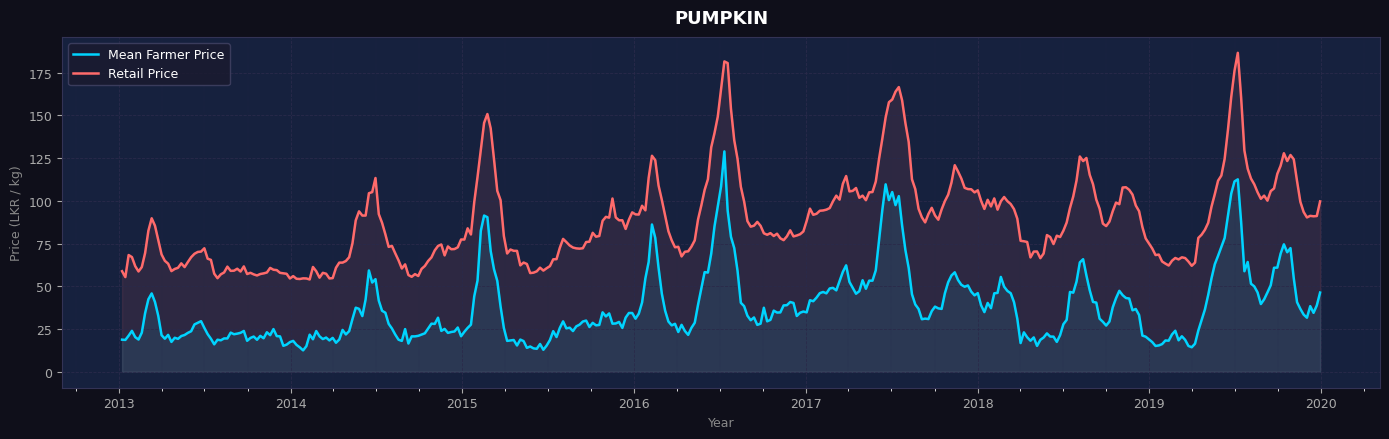

  ✔ PUMPKIN saved → C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing\PUMPKIN_price_trend.png
    Farmer NaN: 0 | Retail NaN: 0


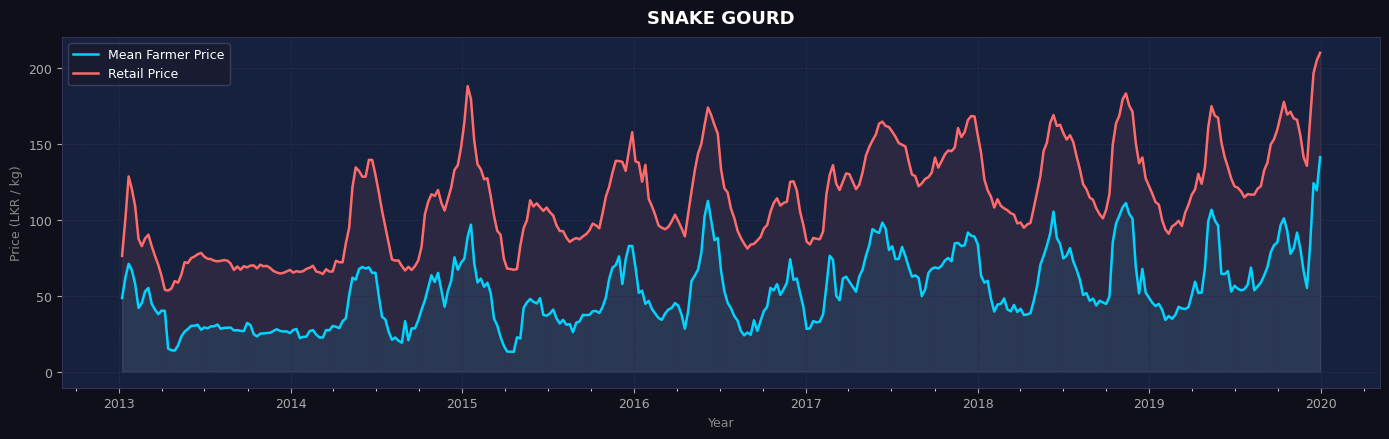

  ✔ SNAKE GOURD saved → C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing\SNAKE_GOURD_price_trend.png
    Farmer NaN: 0 | Retail NaN: 0


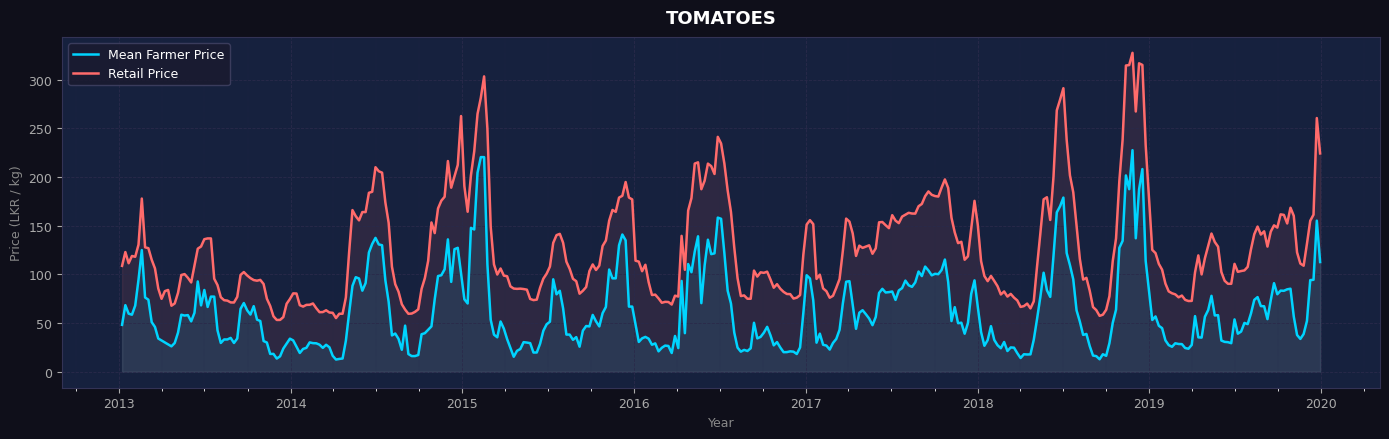

  ✔ TOMATOES saved → C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing\TOMATOES_price_trend.png
    Farmer NaN: 0 | Retail NaN: 0


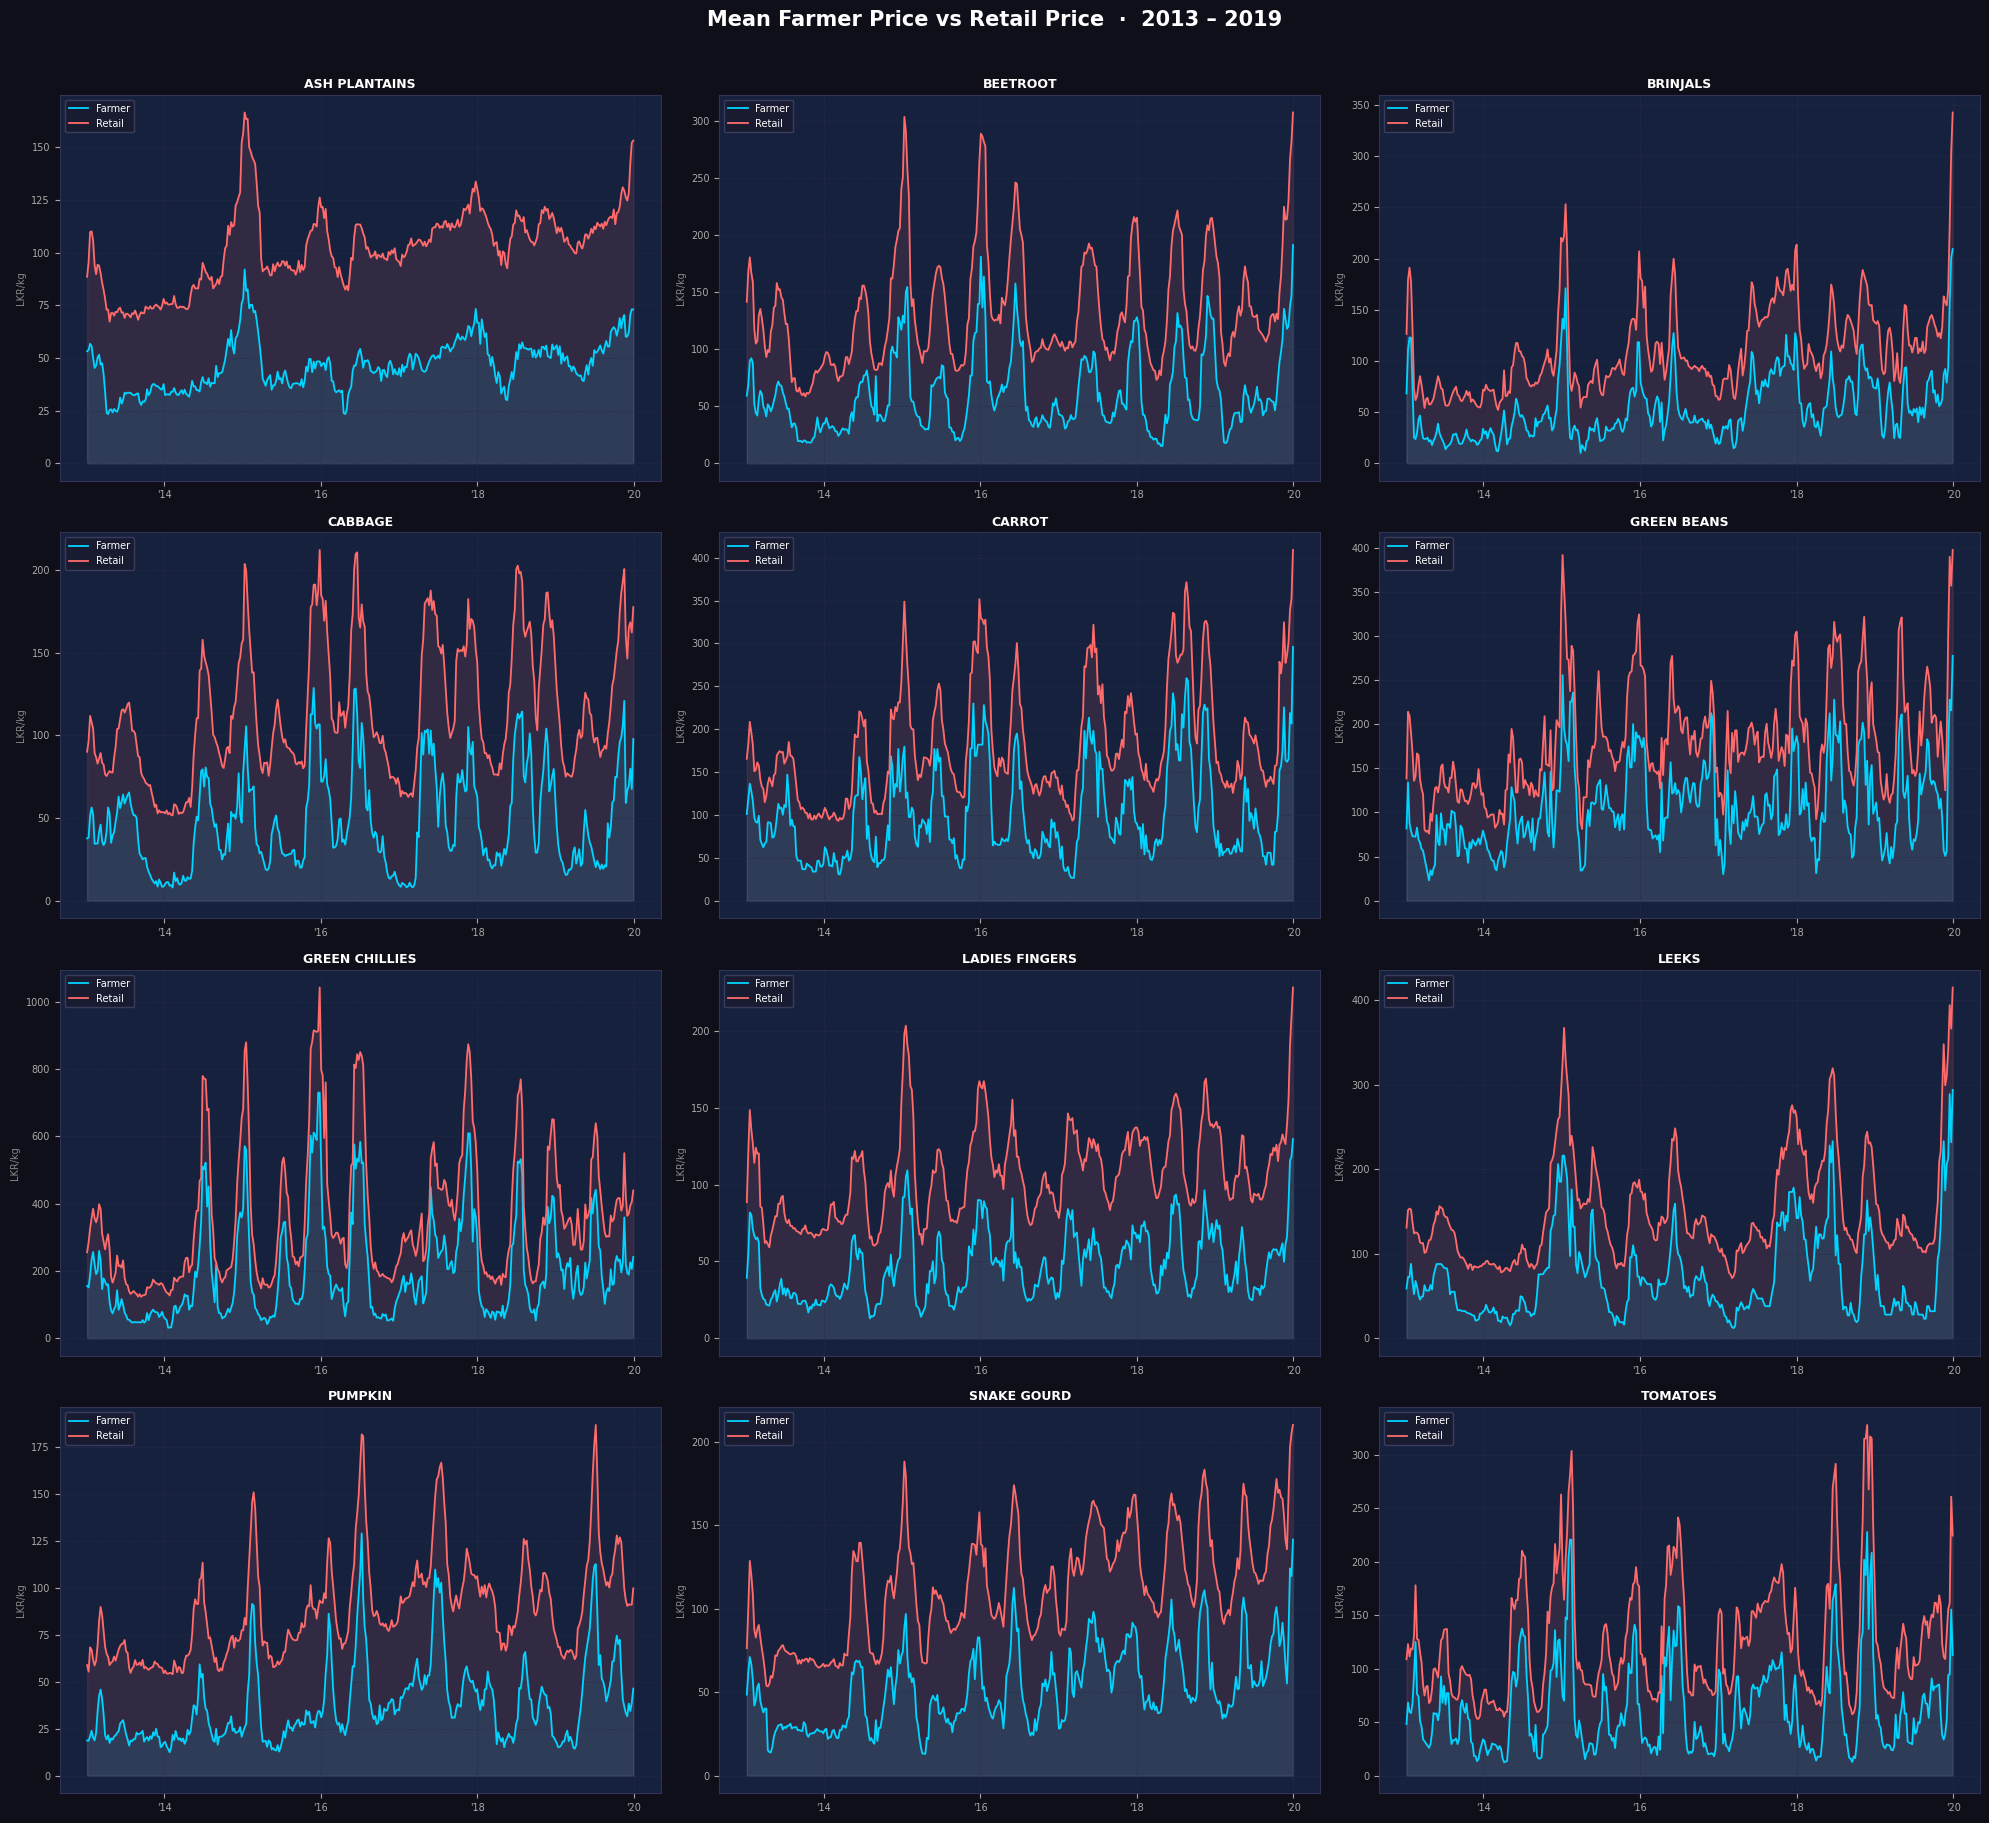


✔ Summary grid saved → C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing\farmer_vs_retail_all_vegetables.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────
FILE      = r'C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Pre Process\Combining DataSets\Final_Combined_data.csv'
SAVE_DIR  = r'C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Visualizing'

FARMER_COLOR = '#00d4ff'
RETAIL_COLOR = '#ff6b6b'
BG           = '#0f0f1a'
PANEL_BG     = '#16213e'
GRID_COLOR   = '#2a2a4a'

# ── Load & prepare ─────────────────────────────────────────────────────────
df = pd.read_csv(FILE, na_values=['NaN'])

df['date'] = pd.to_datetime(
    df['year'].astype(str) +
    df['week'].astype(str).str.replace('w', '-W') + '-1',
    format='%Y-W%W-%w'
)

weekly = (
    df.groupby(['date', 'vegetable_type'])[['mean_farmer_price', 'retail_price']]
    .mean()
    .reset_index()
    .sort_values('date')
)

vegetables = sorted(weekly['vegetable_type'].unique())
print(f"Loaded {len(df):,} rows | {len(vegetables)} vegetables | {df['date'].min().year}–{df['date'].max().year}")

# ── 12 individual charts ───────────────────────────────────────────────────
plt.style.use('dark_background')

for veg in vegetables:
    sub = weekly[weekly['vegetable_type'] == veg].copy()

    fig, ax = plt.subplots(figsize=(14, 4.5), facecolor=BG)
    ax.set_facecolor(PANEL_BG)

    ax.fill_between(sub['date'], sub['mean_farmer_price'], alpha=0.10, color=FARMER_COLOR)
    ax.fill_between(sub['date'], sub['retail_price'],      alpha=0.10, color=RETAIL_COLOR)

    ax.plot(sub['date'], sub['mean_farmer_price'], color=FARMER_COLOR, lw=1.8,
            label='Mean Farmer Price', zorder=3)
    ax.plot(sub['date'], sub['retail_price'],      color=RETAIL_COLOR, lw=1.8,
            label='Retail Price',      zorder=3)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
    ax.tick_params(axis='x', colors='#aaaaaa', labelsize=9)
    ax.tick_params(axis='y', colors='#aaaaaa', labelsize=9)
    ax.grid(which='major', color=GRID_COLOR, lw=0.6, linestyle='--')
    ax.grid(which='minor', color=GRID_COLOR, lw=0.3, linestyle=':')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

    ax.set_title(veg, color='white', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Year', color='#888888', fontsize=9)
    ax.set_ylabel('Price (LKR / kg)', color='#888888', fontsize=9)
    ax.legend(facecolor='#1a1a2e', edgecolor='#444466', labelcolor='white',
              fontsize=9, loc='upper left')

    plt.tight_layout()
    save_path = rf'{SAVE_DIR}\{veg.replace(" ", "_")}_price_trend.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()
    print(f'  ✔ {veg} saved → {save_path}')
    print(f'    Farmer NaN: {sub["mean_farmer_price"].isna().sum()} | Retail NaN: {sub["retail_price"].isna().sum()}')

# ── Summary 4×3 grid ──────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(20, 18), facecolor=BG)
fig.suptitle('Mean Farmer Price vs Retail Price  ·  2013 – 2019',
             color='white', fontsize=15, fontweight='bold', y=1.01)

for i, veg in enumerate(vegetables):
    ax  = axes.flatten()[i]
    sub = weekly[weekly['vegetable_type'] == veg]
    ax.set_facecolor(PANEL_BG)

    ax.fill_between(sub['date'], sub['mean_farmer_price'], alpha=0.12, color=FARMER_COLOR)
    ax.fill_between(sub['date'], sub['retail_price'],      alpha=0.12, color=RETAIL_COLOR)
    ax.plot(sub['date'], sub['mean_farmer_price'], color=FARMER_COLOR, lw=1.3, label='Farmer')
    ax.plot(sub['date'], sub['retail_price'],      color=RETAIL_COLOR, lw=1.3, label='Retail')

    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
    ax.tick_params(colors='#aaaaaa', labelsize=7)
    ax.grid(color=GRID_COLOR, lw=0.4, linestyle='--')
    ax.set_title(veg, color='white', fontsize=9, fontweight='bold', pad=5)
    ax.set_ylabel('LKR/kg', color='#888', fontsize=7)
    ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=7,
              loc='upper left', edgecolor='#444466')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

plt.tight_layout()
grid_path = rf'{SAVE_DIR}\farmer_vs_retail_all_vegetables.png'
plt.savefig(grid_path, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'\n✔ Summary grid saved → {grid_path}')
